In [2]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [3]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind
from src.hypothesis_tests import (
    perform_ttest,
    perform_chi_square
)

In [4]:
df = pd.read_csv("../data/cleaned_insurance_data.csv")

In [5]:
df["LossRatio"] = (
    df["TotalClaims"] / df["TotalPremium"]
)

df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)

df["HasClaim"] = (
    df["TotalClaims"] > 0
).astype(int)

In [7]:
print(len(gauteng))
print(len(western_cape))
print(gauteng.isnull().sum())
print(western_cape.isnull().sum())

0
0
0
0


In [8]:
df = df[df["TotalPremium"] > 0]

df["LossRatio"] = (
    df["TotalClaims"] / df["TotalPremium"]
)

In [9]:
df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(subset=["LossRatio"])

In [10]:
df["Province"].value_counts()

Province
Addis Ababa    3567
Oromia         2446
Amhara         1999
Somali         1184
Tigray          804
Name: count, dtype: int64

In [11]:
top_provinces = (
    df["Province"]
    .value_counts()
    .head(2)
)

top_provinces

Province
Addis Ababa    3567
Oromia         2446
Name: count, dtype: int64

In [19]:
province1 = df[
    df["Province"] == "Addis Ababa"
]["LossRatio"]

province2 = df[
    df["Province"] == "Oromia"
]["LossRatio"]

print(len(province1))
print(len(province2))

3567
2446


In [20]:
df["LossRatio"] = (
    df["TotalClaims"] / df["TotalPremium"]
)

df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(subset=["LossRatio"])

In [21]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(
    province1,
    province2,
    nan_policy="omit"
)

print("P-value:", p)

P-value: 0.6171247791877275


We fail to reject the null hypothesis. There is no strong statistical evidence of insurance risk differences between Addis Ababa and Oromia.

In [22]:
severity_df = df[df["TotalClaims"] > 0]

In [28]:
zip1 = severity_df[
    severity_df["ZipCode"] == 10001
]["TotalClaims"]

zip2 = severity_df[
    severity_df["ZipCode"] == 20001
]["TotalClaims"]

stat2, p2 = ttest_ind(
    zip1,
    zip2,
    nan_policy="omit"
)

print("P-value:", p2)

P-value: 0.6669896177603862


no strong evidence

In [24]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType',
       'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD',
       'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims',
       'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate',
       'ZipCode', 'TransactionDate', 'LossRatio', 'Margin', 'HasClaim'],
      dtype='str')

In [26]:
df["ZipCode"].unique()[:20]

array([10002, 10001, 20001, 40005, 50002, 30003, 20005, 20004, 30005,
       30002, 10004, 10003, 50004, 20002, 30004, 50001, 10005, 50005,
       40001, 20003])

In [29]:
margin1 = df[
    df["ZipCode"] == 10001
]["Margin"]

margin2 = df[
    df["ZipCode"] == 20001
]["Margin"]

stat3, p3 = ttest_ind(
    margin1,
    margin2,
    nan_policy="omit"
)

print("P-value:", p3)

P-value: 0.07707556609017775


There is a statistically significant difference between the selected zip codes.

In [31]:
contingency = pd.crosstab(
    df["Gender"],
    df["HasClaim"]
)

contingency

HasClaim,0,1
Gender,,
Female,4348,790
Male,4117,745


In [33]:
from scipy.stats import chi2_contingency
chi2, p4, dof, expected = chi2_contingency(
    contingency
)

print("P-value:", p4)

P-value: 0.9638306173980254


There is no strong statistical evidence

In [34]:
results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk",
        "Zip Code Severity",
        "Zip Code Margin",
        "Gender Claim Frequency"
    ],

    "P-Value": [
        p,
        p2,
        p3,
        p4
    ]
})

results

,Hypothesis,P-Value
0,Province Risk,0.617125
1,Zip Code Severity,0.666990
2,Zip Code Margin,0.077076
3,Gender Claim Frequency,0.963831


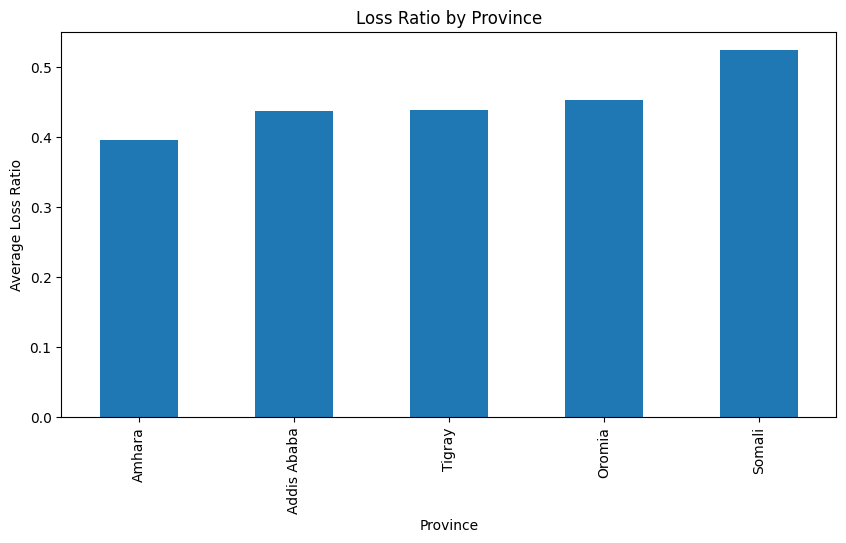

In [36]:
import matplotlib.pyplot as plt
province_loss = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))

province_loss.plot(kind="bar")

plt.title("Loss Ratio by Province")

plt.ylabel("Average Loss Ratio")

plt.show()